# 03 — Statistical Analysis

## Objective

This notebook statistically validates the main patterns identified during the EDA and separates three related but distinct questions:

1. **Occurrence:** which operational conditions differ between MD and non-MD observations?
2. **Absolute severity:** among MD observations, which variables are associated with larger lost quantities?
3. **Context:** is MD occurrence associated with planning-group, customer, UAT or destination?

The analysis is descriptive/inferential, not causal. Same-day operational variables are valid here because this notebook analyses contemporaneous associations. The predictive model is handled later with leakage-safe D-7/D-14/D-21/D-28 features.


## Statistical strategy

The data contain skewed distributions, extreme values and heterogeneous operational scales. Therefore:

- **Mann–Whitney U** compares MD/non-MD or severity groups without assuming normality.
- **Rank-biserial correlation** reports effect size, because a small p-value does not imply a large practical difference.
- **Benjamini–Hochberg FDR** corrects for multiple testing.
- **Spearman's rho** measures monotonic association with continuous lost quantity.
- **Chi-square + Cramér's V** assess categorical association.
- **Cluster bootstrap by `Grupo_raiz`** estimates 95% confidence intervals while preserving within-group dependence.

The same methods, thresholds and random seed used in the reviewed project are retained.


### Reading guide: question, evidence and magnitude

The analyses address different questions: **whether a Missed Delivery occurs**, **how many pieces are lost when it occurs**, and **how occurrence relates to logistical context**. Keeping these questions separate avoids interpreting a factor associated with loss volume as if it also explained the probability of failure.

Under the null hypothesis and the assumptions of the test, the p-value is the probability of obtaining a result at least as extreme as the observed result. It is not the probability that the null hypothesis is true. A small p-value does not necessarily imply an important effect, which is why effect sizes and confidence intervals are also reported.

Nonparametric tests use ranks and do not require normality, but they still have assumptions. In particular, the conventional tests used here assume independent observations. Because the same `Grupo_raiz` appears on multiple dates, their p-values require caution; the cluster bootstrap complements uncertainty assessment for the selected effects.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, spearmanr, chi2_contingency
from statsmodels.stats.multitest import multipletests


In [2]:
df = pd.read_csv("../../data/processed/dataset_clean.csv")
df["Fecha"] = pd.to_datetime(df["Fecha"])

print("Shape:", df.shape)
df.head()


Shape: (33971, 27)


,Fecha,Grupo_raiz,FabricacionSemana,RitmoSemana,CumpFabRit,ExpedidasSemana,Demanda,CumpExpDem,StockFin,StockReal,...,EntregasPrev,DemandActual,CumpTotal,customer,uat,destination,lost,delivered,requested,missed_delivery
0,2025-01-02,6526S,0,-230,0.0,0,1515,0.0,910,2816,...,2304,5764,40.000000,010172,UATZ3,010172D01,0,192,192,0
1,2025-01-02,6695S0020,0,-1,0.0,0,15,0.0,64,324,...,63,57,110.500000,097946,UATP11,097946D03,0,18,18,0
2,2025-01-02,6695S0050,0,-51,0.0,0,295,0.0,93,270,...,1602,1121,142.899994,097946,UATM11,097946D03,45,45,90,1
3,2025-01-02,6695T,0,-280,0.0,0,1515,0.0,793,1017,...,5229,5757,90.800003,097946,UATE5,097946D03,0,378,378,0
4,2025-01-02,6768S,0,-100,0.0,0,500,0.0,400,1208,...,1850,1900,97.400002,093929,UATP19,093929D01,0,120,120,0


## Derived analysis variables

`requested = delivered + lost` is reconstructed only for descriptive severity analysis and is never used as a predictive feature.

Six absolute operational gaps complement the original compliance ratios.


In [3]:
df["requested"] = df["delivered"] + df["lost"]
df["missed_delivery"] = (df["lost"] > 0).astype(int)

df["production_gap"] = df["FabricacionSemana"] - df["RitmoSemana"]
df["shipment_demand_gap"] = df["ExpedidasSemana"] - df["Demanda"]
df["stock_gap"] = df["StockReal"] - df["StockFin"]
df["accumulated_production_gap"] = df["AcumFab"] - df["AcumRitmo"]
df["accumulated_delivery_gap"] = df["AcumEnvio"] - df["AcumDemanda"]
df["planned_delivery_gap"] = df["EntregasPrev"] - df["DemandActual"]

operational_absolute_cols = [
    "FabricacionSemana", "RitmoSemana", "ExpedidasSemana", "Demanda",
    "StockFin", "StockReal", "AcumFab", "AcumRitmo",
    "AcumEnvio", "AcumDemanda", "EntregasPrev", "DemandActual"
]

operational_ratio_cols = [
    "CumpFabRit", "CumpExpDem", "CumpStock",
    "PorcenCump", "PorcenCumpto", "CumpTotal"
]

gap_cols = [
    "production_gap", "shipment_demand_gap", "stock_gap",
    "accumulated_production_gap", "accumulated_delivery_gap",
    "planned_delivery_gap"
]

severity_test_cols = (
    operational_absolute_cols
    + operational_ratio_cols
    + gap_cols
)

occurrence_test_cols = [
    "CumpStock", "CumpExpDem", "CumpFabRit",
    "PorcenCump", "PorcenCumpto", "CumpTotal",
    "stock_gap", "shipment_demand_gap", "production_gap",
    "accumulated_production_gap",
    "accumulated_delivery_gap",
    "planned_delivery_gap"
]

categorical_test_cols = [
    "Grupo_raiz", "customer", "destination", "uat"
]


### Meaning of the derived variables

`missed_delivery` equals 1 when `lost > 0`, separating observations with and without a delivery failure. `requested` is reconstructed by adding delivered and lost pieces: it provides a descriptive denominator, but is not an independent measurement of the original demand.

Each gap retains the units of the quantities being subtracted. For example, a negative `shipment_demand_gap` means shipments are below demand; a negative `stock_gap` means `StockReal` is below `StockFin`. Interpretation depends on the specific subtraction: a positive sign does not automatically indicate better operational performance.

Absolute quantities also reflect operational scale. Relative indicators provide another perspective, although they do not by themselves remove confounding between volume, context and fulfilment.


## Reusable statistical helpers

The same Mann–Whitney logic is used for occurrence, high-volume MD and complete-failure comparisons. Consolidating it into one function removes duplicated code without changing the test, U statistic, rank-biserial effect size or FDR correction.


### Rationale for Mann?Whitney U and effect size

Mann?Whitney jointly ranks values from two groups and compares their ranks. The conventional null hypothesis is that both samples come from the same distribution; the two-sided alternative allows differences in either direction. It is useful with skewed distributions and extreme values because it does not directly compare means under a normality assumption.

It should not simply be described as a test of medians: that interpretation requires additional assumptions about comparable distribution shapes and dispersion. The table medians describe the groups, whereas the test uses all their ranks.

The function calls `mannwhitneyu(g1, g0)` and calculates:

$$r_{rb}=\frac{2U}{n_1n_0}-1.$$

A positive result means group 1 values tend to exceed group 0 values; a negative result indicates the reverse. Ties contribute half a point to U. The scale runs from -1 to 1. The code labels effects as negligible, small, moderate or large using absolute-value cutoffs of 0.10, 0.30 and 0.50. These are approximate interpretation guidelines, not universal thresholds of business relevance.

### Why p-values are adjusted

Testing many variables increases the opportunity to find significant results by chance. `multipletests(..., method="fdr_bh")` applies Benjamini-Hochberg at the 0.05 level. Under its validity conditions, it controls the expected proportion of false discoveries among results declared significant, not the probability that each particular result is false.

The adjustment is applied separately within each table: occurrence, high volume, complete failure, correlations and context. It is not a global correction across the notebook and does not correct dependence between rows. In addition, `.dropna()` uses the available observations for each variable; sample sizes can therefore differ between comparisons when values are missing.


In [4]:
def effect_interpretation(r):
    r = abs(r)
    if r < 0.10:
        return "negligible"
    if r < 0.30:
        return "small"
    if r < 0.50:
        return "moderate"
    return "large"


def mann_whitney_table(data, group_col, variables, group_0=0, group_1=1):
    records = []

    for col in variables:
        g0 = data.loc[data[group_col] == group_0, col].dropna()
        g1 = data.loc[data[group_col] == group_1, col].dropna()

        U, p = mannwhitneyu(g1, g0, alternative="two-sided")

        records.append({
            "variable": col,
            "n_0": len(g0),
            "n_1": len(g1),
            "median_0": g0.median(),
            "median_1": g1.median(),
            "U_statistic": U,
            "p_value": p,
            "rank_biserial": 2 * U / (len(g1) * len(g0)) - 1
        })

    results = pd.DataFrame(records)
    results["abs_effect_size"] = results["rank_biserial"].abs()
    results["effect"] = results["rank_biserial"].apply(effect_interpretation)

    reject, p_adj, _, _ = multipletests(
        results["p_value"],
        alpha=0.05,
        method="fdr_bh"
    )

    results["p_adjusted"] = p_adj
    results["significant"] = reject

    return results.sort_values(
        "abs_effect_size",
        ascending=False
    ).reset_index(drop=True)


def cramers_v(contingency_table):
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    n = contingency_table.values.sum()
    r, k = contingency_table.shape
    phi2 = chi2 / n

    v = np.sqrt(
        phi2 / min(k - 1, r - 1)
    )

    return chi2, p, dof, v, expected


# Part A — Missed Delivery Occurrence

The occurrence analysis compares MD vs non-MD observations. A significant p-value indicates evidence of a distributional difference; the rank-biserial correlation quantifies its magnitude and direction.


In [5]:
mw_results = mann_whitney_table(
    df,
    group_col="missed_delivery",
    variables=occurrence_test_cols
)

mw_results = mw_results.rename(columns={
    "n_0": "n_no_md",
    "n_1": "n_md",
    "median_0": "median_no_md",
    "median_1": "median_md"
})

mw_results[
    [
        "variable",
        "median_no_md",
        "median_md",
        "rank_biserial",
        "effect",
        "p_adjusted",
        "significant"
    ]
]


,variable,median_no_md,median_md,rank_biserial,effect,p_adjusted,significant
0,CumpStock,107.199997,82.300003,-0.186238,small,2.143654e-57,True
1,planned_delivery_gap,0.000000,66.000000,0.156916,small,2.981197e-41,True
2,CumpTotal,100.000000,101.900002,0.149027,small,1.766317e-37,True
3,stock_gap,30.000000,-40.000000,-0.105003,small,2.976514e-19,True
4,PorcenCump,94.699997,91.099998,-0.053923,negligible,7.211894e-06,True
5,PorcenCumpto,96.300003,92.599998,-0.050067,negligible,2.886647e-05,True
6,CumpFabRit,94.000000,90.199997,-0.045252,negligible,1.509152e-04,True
7,CumpExpDem,84.599998,77.000000,-0.044307,negligible,1.853634e-04,True
8,shipment_demand_gap,-89.000000,-144.000000,-0.021001,negligible,9.208579e-02,False
9,accumulated_delivery_gap,-10.000000,-7.000000,0.020112,negligible,9.796787e-02,False


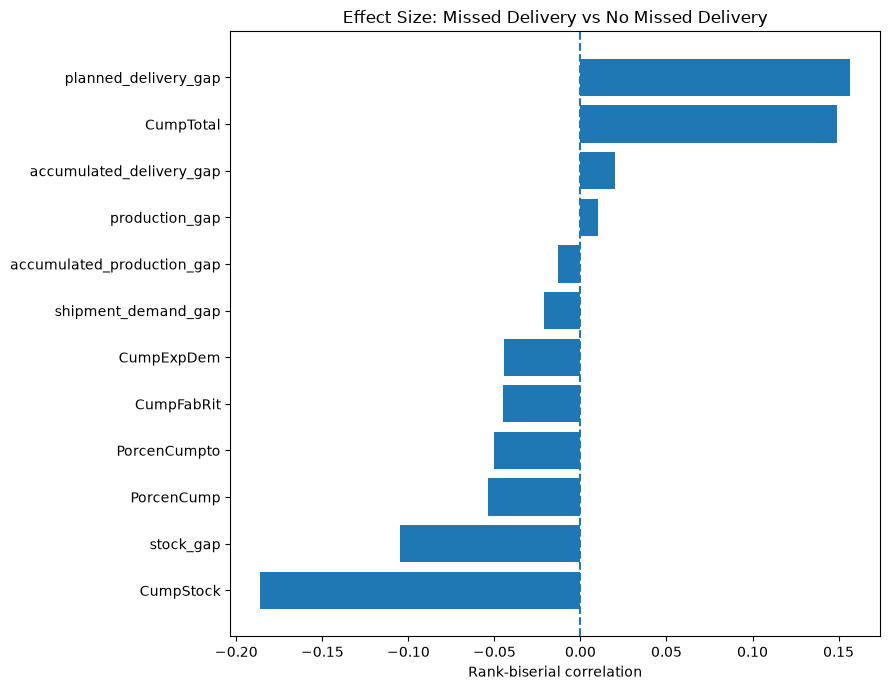

In [6]:
effect_plot = mw_results.sort_values("rank_biserial")

plt.figure(figsize=(9, 7))
plt.barh(
    effect_plot["variable"],
    effect_plot["rank_biserial"]
)
plt.axvline(0, linestyle="--")
plt.xlabel("Rank-biserial correlation")
plt.title("Effect Size: Missed Delivery vs No Missed Delivery")
plt.tight_layout()
plt.show()


### Occurrence findings

The reviewed dataset shows the clearest numerical occurrence effect for `CumpStock` (rank-biserial ≈ -0.186), followed by `planned_delivery_gap` (≈ 0.157), `CumpTotal` (≈ 0.149) and `stock_gap` (≈ -0.105). These are small effects.

This supports a multivariable interpretation: no single same-day numerical variable strongly separates MD from non-MD observations.


### Interpreting the occurrence table and plot

Here, group 1 contains Missed Deliveries and group 0 contains observations without a Missed Delivery. The `CumpStock` effect of approximately -0.186 therefore indicates generally lower values when MD occurs. Its medians are 82.30 versus 107.20. In contrast, `planned_delivery_gap` has a positive effect of approximately 0.157.

The plot displays effect direction and magnitude, not failure probabilities. Eight of the twelve comparisons have `p_adjusted < 0.05`, but none reaches a moderate effect under the function's cutoffs. There is evidence of association, with substantial overlap between groups. This motivates exploring combinations of variables; it does not yet demonstrate that a model will predict well.


# Part B — Missed Delivery Severity

Occurrence and severity are different questions. Severity is analysed only within MD observations.

Two complementary views are retained:

- **high-volume MD:** the upper 10% of absolute lost quantity;
- **continuous severity:** Spearman association with `lost`.

Relative severity is additionally described through complete vs partial failure.


In [7]:
md_df = df.loc[
    df["missed_delivery"] == 1
].copy()

high_volume_threshold = md_df["lost"].quantile(0.90)
md_df["high_volume_md"] = (
    md_df["lost"] >= high_volume_threshold
).astype(int)

print(
    f"High-volume MD threshold: "
    f"{high_volume_threshold:.0f} lost pieces"
)

md_df["high_volume_md"].value_counts()


High-volume MD threshold: 1341 lost pieces


high_volume_md
0    2443
1     272
Name: count, dtype: int64

## High-volume MD comparison

The P90 split is an exploratory severity device, not a business threshold. It isolates the largest absolute-loss events while preserving the original `lost` variable for continuous analysis.


In [8]:
severity_mw = mann_whitney_table(
    md_df,
    group_col="high_volume_md",
    variables=severity_test_cols
)

severity_mw = severity_mw.rename(columns={
    "n_0": "n_regular",
    "n_1": "n_high",
    "median_0": "median_regular",
    "median_1": "median_high"
})

severity_mw[
    [
        "variable",
        "median_regular",
        "median_high",
        "rank_biserial",
        "effect",
        "p_adjusted",
        "significant"
    ]
]


,variable,median_regular,median_high,rank_biserial,effect,p_adjusted,significant
0,EntregasPrev,3520.000000,12648.000000,0.586046,large,2.189126e-55,True
1,Demanda,870.000000,3050.000000,0.573401,large,2.422754e-53,True
2,DemandActual,3366.000000,12080.500000,0.555586,large,2.679040e-50,True
3,StockReal,496.000000,1587.000000,0.485350,moderate,1.014475e-38,True
4,StockFin,546.000000,2228.500000,0.476512,moderate,1.905289e-37,True
5,RitmoSemana,495.000000,2025.000000,0.469556,moderate,1.768581e-36,True
6,FabricacionSemana,466.000000,2050.500000,0.455062,moderate,1.610420e-34,True
7,AcumRitmo,990.000000,4385.000000,0.445410,moderate,4.488939e-33,True
8,AcumDemanda,970.000000,4275.500000,0.442268,moderate,1.106279e-32,True
9,AcumFab,975.000000,4060.000000,0.438815,moderate,2.848752e-32,True


### High-volume findings

The strongest high-volume effects are associated with operational exposure: `EntregasPrev`, `Demanda` and `DemandActual` show large rank-biserial effects in the reviewed data. Larger flows have greater capacity to generate large absolute losses; this is an association with scale, not evidence of causality.


### Conclusion on high-volume losses

Of the 2,715 MD observations, 272 have at least 1,341 lost pieces and 2,443 fall below that threshold. The 90th percentile is estimated from this sample: it is not a contractual limit, and ties at the threshold can make the selected proportion differ from 10%.

In this comparison, group 1 is the high-volume group. The effects for `EntregasPrev` (0.586), `Demanda` (0.573) and `DemandActual` (0.556) are large under the chosen cutoffs. For example, median `EntregasPrev` increases from 3,520 to 12,648 pieces.

The result is consistent with operational exposure: a larger operation can lose more pieces. It does not demonstrate that increasing demand causes delivery failures. This conclusion also applies exclusively to observations that already have an MD.


## Relative severity: complete vs partial failure

Absolute severity and relative severity are not equivalent. A delivery can lose many pieces while still being partial, whereas a smaller obligation can fail completely.

`loss_rate` is therefore calculated as `lost / requested`. The natural 100% boundary defines complete failure; no additional percentile-based relative-severity threshold is introduced.


In [9]:
md_df["loss_rate"] = (
    md_df["lost"]
    / md_df["requested"]
    * 100
)

md_df["complete_failure"] = (
    md_df["loss_rate"] == 100
).astype(int)

complete_failure_count = md_df["complete_failure"].sum()
complete_failure_pct = (
    complete_failure_count
    / len(md_df)
    * 100
)

print(
    f"Complete MD failures: "
    f"{complete_failure_count} "
    f"({complete_failure_pct:.2f}% of all MD observations)"
)

display(
    md_df["loss_rate"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

md_df["complete_failure"].value_counts()


Complete MD failures: 1266 (46.63% of all MD observations)


count    2715.000000
mean       67.316895
std        34.917901
min         0.101937
50%        75.539568
75%       100.000000
90%       100.000000
95%       100.000000
99%       100.000000
max       100.000000
Name: loss_rate, dtype: float64

complete_failure
0    1449
1    1266
Name: count, dtype: int64

In [10]:
complete_mw = mann_whitney_table(
    md_df,
    group_col="complete_failure",
    variables=severity_test_cols
)

complete_mw = complete_mw.rename(columns={
    "n_0": "n_partial",
    "n_1": "n_complete",
    "median_0": "median_partial",
    "median_1": "median_complete"
})

complete_mw[
    [
        "variable",
        "median_partial",
        "median_complete",
        "rank_biserial",
        "effect",
        "p_adjusted",
        "significant"
    ]
]


,variable,median_partial,median_complete,rank_biserial,effect,p_adjusted,significant
0,RitmoSemana,900.000000,346.500000,-0.272512,small,3.216638e-33,True
1,EntregasPrev,5192.000000,2817.500000,-0.257835,small,4.600804e-30,True
2,DemandActual,5198.000000,2415.000000,-0.256855,small,5.130040e-30,True
3,Demanda,1350.000000,677.500000,-0.250850,small,6.912004e-29,True
4,FabricacionSemana,803.000000,342.500000,-0.250557,small,6.912004e-29,True
5,ExpedidasSemana,820.000000,380.000000,-0.244112,small,1.202969e-27,True
6,StockReal,720.000000,405.000000,-0.219052,small,2.097795e-22,True
7,AcumEnvio,1500.000000,740.000000,-0.210546,small,6.887900e-21,True
8,AcumRitmo,1596.000000,760.000000,-0.208790,small,1.430332e-20,True
9,AcumDemanda,1551.000000,782.500000,-0.207461,small,2.253201e-20,True


### Conclusion on complete and partial failures

The code expresses `loss_rate` as a percentage: `lost / requested * 100`. With nonnegative quantities and a positive denominator, 100% corresponds to delivering none of the pieces reconstructed as requested.

There are 1,266 complete failures, representing 46.63% of MD observations, versus 1,449 partial failures. The median loss percentage is 75.54%. The concentration of values at 100% makes distinguishing complete from partial failures useful, instead of introducing another percentile cutoff.

Here, group 1 contains complete failures. Negative effects for `RitmoSemana` (-0.273), `EntregasPrev` (-0.258) and `DemandActual` (-0.257) indicate lower values in that group; these are small effects under the function's cutoffs. Losing a large quantity and losing 100% therefore do not describe the same operational profile. These percentages are calculated among MD observations, not among all observations.


## Continuous absolute severity

The P90 comparison discards some information by converting a continuous quantity into two groups. Spearman's rho therefore provides the primary continuous check of how operational variables vary with `lost`.


### Rationale for Spearman correlation

Spearman calculates the correlation between the ranks of two variables:

$$\rho_s=\operatorname{corr}(\operatorname{rank}(X),\operatorname{rank}(\mathrm{lost})).$$

It detects a monotonic relationship: one variable tends to increase or decrease as the other increases, even when the relationship is not a straight line. Its scale runs from ?1 to 1. A value near zero indicates little monotonic association, but does not rule out relationships of other shapes.

The code retains `lost` as a continuous quantity, removes missing values pairwise and tests the null hypothesis of zero Spearman correlation before applying FDR adjustment. This complements the P90 comparison without losing the ordering of quantities within each group. It does not adjust for other variables or establish causality, and its coefficient is not a percentage of explained variance.


In [11]:
severity_corr_records = []

for col in severity_test_cols:
    subset = md_df[[col, "lost"]].dropna()
    rho, p_value = spearmanr(
        subset[col],
        subset["lost"]
    )

    severity_corr_records.append({
        "variable": col,
        "n": len(subset),
        "spearman_rho": rho,
        "p_value": p_value
    })

severity_corr_results = pd.DataFrame(
    severity_corr_records
)

valid_p = severity_corr_results["p_value"].notna()

severity_corr_results["p_adjusted"] = np.nan
severity_corr_results["significant"] = False

if valid_p.any():
    reject, p_adj, _, _ = multipletests(
        severity_corr_results.loc[
            valid_p,
            "p_value"
        ],
        alpha=0.05,
        method="fdr_bh"
    )

    severity_corr_results.loc[
        valid_p,
        "p_adjusted"
    ] = p_adj

    severity_corr_results.loc[
        valid_p,
        "significant"
    ] = reject

severity_corr_results["abs_spearman"] = (
    severity_corr_results["spearman_rho"].abs()
)

severity_corr_results = (
    severity_corr_results
    .sort_values(
        "abs_spearman",
        ascending=False
    )
    .reset_index(drop=True)
)

severity_corr_results[
    [
        "variable",
        "n",
        "spearman_rho",
        "p_adjusted",
        "significant"
    ]
]


,variable,n,spearman_rho,p_adjusted,significant
0,EntregasPrev,2715,0.497639,1.721825e-168,True
1,Demanda,2715,0.476560,6.577322e-153,True
2,DemandActual,2715,0.467832,7.929253e-147,True
3,StockFin,2715,0.416989,6.476502e-114,True
4,RitmoSemana,2715,0.384822,7.252082e-96,True
5,AcumRitmo,2715,0.374199,2.205195e-90,True
6,StockReal,2715,0.373183,6.271620e-90,True
7,AcumDemanda,2715,0.367895,2.641851e-87,True
8,AcumFab,2715,0.357435,3.385539e-82,True
9,FabricacionSemana,2715,0.355601,2.338277e-81,True


### Severity findings

The continuous analysis confirms the high-volume comparison. In the reviewed dataset, `EntregasPrev` (ρ ≈ 0.498), `Demanda` (ρ ≈ 0.477) and `DemandActual` (ρ ≈ 0.468) have the strongest associations with absolute lost quantity.

The complete-failure analysis shows a different pattern, confirming that **absolute loss volume and relative failure severity are distinct phenomena**.


# Part C — Categorical Context

Chi-square tests whether MD occurrence is independent of each categorical context variable. Cramér's V quantifies association strength.

Because small expected frequencies can weaken the Chi-square approximation, low-support categories are grouped into `OTHER` using the same prevalence-based rule as the reviewed notebook.


In [12]:
expected_frequency_records = []

for col in categorical_test_cols:
    contingency = pd.crosstab(
        df[col],
        df["missed_delivery"]
    )

    _, _, _, expected = chi2_contingency(
        contingency
    )

    cells_below_5 = (expected < 5).sum()

    expected_frequency_records.append({
        "variable": col,
        "total_cells": expected.size,
        "cells_expected_below_5": cells_below_5,
        "pct_expected_below_5": (
            cells_below_5 / expected.size * 100
        ),
        "min_expected": expected.min()
    })

expected_frequency_results = pd.DataFrame(
    expected_frequency_records
)

expected_frequency_results


,variable,total_cells,cells_expected_below_5,pct_expected_below_5,min_expected
0,Grupo_raiz,452,92,20.353982,0.079921
1,customer,110,20,18.181818,0.079921
2,destination,168,47,27.976190,0.079921
3,uat,42,3,7.142857,0.399606


### Rationale for chi-square and category grouping

`pd.crosstab` counts observations with and without MD within each category. Under the null hypothesis of independence, the expected frequency of a cell is:

$$E_{ij}=\frac{n_{i\cdot}\,n_{\cdot j}}{n}.$$

Chi-square compares observed counts with these expected counts. For these tables, the degrees of freedom equal `(number of categories ? 1)`. Small expected frequencies can weaken the approximation used to obtain the p-value, which is why they are inspected before and after grouping.

With MD prevalence of approximately 0.0799, a category of size $m$ would have $m\times0.0799$ expected MD observations under independence. The rule `ceil(5 / md_prevalence)` gives a minimum support of 63 observations. This is a practical statistical stability rule, not a risk classification.

Smaller categories are pooled into `OTHER`. This reduces fragmentation but also hides differences between them. The residual `OTHER` category can itself remain small, so the subsequent diagnostic is still necessary.

Cram?r's V normalizes the statistic to measure association strength:

$$V=\sqrt{\frac{\chi^2}{n\min(r-1,k-1)}}.$$

It ranges from 0 to 1 and has no sign: it does not by itself identify which customer or destination has higher risk. Its magnitude also depends on table structure, so qualitative strength labels should be treated as approximate guidelines.


In [13]:
md_prevalence = df["missed_delivery"].mean()

min_category_support = int(
    np.ceil(5 / md_prevalence)
)

print(f"MD prevalence: {md_prevalence:.4f}")
print(
    f"Minimum category support: "
    f"{min_category_support} observations"
)

df_cat = df.copy()

for col in categorical_test_cols:
    counts = df_cat[col].value_counts()

    rare_categories = counts[
        counts < min_category_support
    ].index

    df_cat[col] = df_cat[col].where(
        ~df_cat[col].isin(rare_categories),
        "OTHER"
    )

for col in categorical_test_cols:
    print(
        f"{col}: "
        f"{df[col].nunique()} -> "
        f"{df_cat[col].nunique()} categories"
    )


MD prevalence: 0.0799
Minimum category support: 63 observations
Grupo_raiz: 226 -> 145 categories
customer: 55 -> 40 categories
destination: 84 -> 49 categories
uat: 21 -> 20 categories


In [14]:
categorical_records = []

for col in categorical_test_cols:
    contingency = pd.crosstab(
        df_cat[col],
        df_cat["missed_delivery"]
    )

    chi2, p, dof, v, expected = cramers_v(
        contingency
    )

    cells_below_5 = (expected < 5).sum()

    categorical_records.append({
        "variable": col,
        "categories": df_cat[col].nunique(),
        "chi2": chi2,
        "degrees_of_freedom": dof,
        "p_value": p,
        "cramers_v": v,
        "cells_expected_below_5": cells_below_5,
        "pct_expected_below_5": (
            cells_below_5 / expected.size * 100
        ),
        "min_expected_frequency": expected.min()
    })

categorical_results_grouped = pd.DataFrame(
    categorical_records
)

reject_cat, p_adj_cat, _, _ = multipletests(
    categorical_results_grouped["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

categorical_results_grouped["p_adjusted"] = p_adj_cat
categorical_results_grouped["significant"] = reject_cat

categorical_results_grouped.sort_values(
    "cramers_v",
    ascending=False
)


,variable,categories,chi2,degrees_of_freedom,p_value,cramers_v,cells_expected_below_5,pct_expected_below_5,min_expected_frequency,p_adjusted,significant
2,destination,49,4517.332347,48,0.0,0.364659,0,0.0,5.434635,0.0,True
0,Grupo_raiz,145,4005.642022,144,0.0,0.343385,0,0.0,5.434635,0.0,True
1,customer,40,3599.811714,39,0.0,0.325526,0,0.0,5.434635,0.0,True
3,uat,20,1849.250822,19,0.0,0.233316,1,2.5,1.758264,0.0,True


### Categorical findings

After grouping rare categories, the reviewed dataset shows moderate Cramér's V associations for `destination` (≈ 0.365), `Grupo_raiz` (≈ 0.343) and `customer` (≈ 0.326), with a smaller association for `uat` (≈ 0.233).

These associations support retaining logistical context as candidate predictive information, while remaining descriptive rather than causal.


### Scope of the categorical results

After grouping, no expected frequencies below 5 remain for `Grupo_raiz`, `customer` or `destination`. For `uat`, one cell remains below 5, representing 2.5% of cells, with a minimum expected frequency of approximately 1.76. Grouping improves this diagnostic but does not make repeated observations independent.

`destination` has the highest observed V (0.365), followed by `Grupo_raiz` (0.343), `customer` (0.326) and `uat` (0.233). These are marginal associations: because the dimensions may be related to one another, their effects should not be added or interpreted as independent contributions.

P-values displayed as `0.0` reflect numerical representation limits for extremely small values, not mathematically exact zero probabilities.


# Part D — Cluster-bootstrap robustness

Rows are not fully independent because the same `Grupo_raiz` appears repeatedly over time. The bootstrap therefore resamples entire planning groups rather than individual rows.

The final configuration remains **500 bootstrap replications with seed 42**, matching the reviewed project. For quick development only, `FAST_MODE=True` can reduce the repetitions; the final notebook should be executed with `FAST_MODE=False`.


### Why resample entire groups?

The bootstrap approximates an estimator's variability by repeating the analysis on samples drawn with replacement. Here, the resampling unit is `Grupo_raiz`: each selected group contributes all its rows and can appear multiple times. This preserves dependence within groups, which would be lost by treating every row as an independent unit.

The code retains the original identifier in `_cluster_grupo_raiz`, even when the analysed category has been changed to `OTHER`. Category grouping therefore does not artificially merge the resampling units.

The 2.5th and 97.5th percentiles of the replicates form the 95% bootstrap interval; `ci_width` summarizes its width. Seed 42 makes resampling reproducible, and 500 replicates provide an approximation subject to Monte Carlo variability. Replicates for which the statistic cannot be calculated are recorded as `NaN` and omitted when computing percentiles.

The procedure assumes sufficiently independent and representative groups. It does not automatically account for shared temporal shocks across groups or future distribution changes. Intervals are calculated individually for twelve selected effects: they are not simultaneous intervals adjusted for multiplicity, nor do they replace the earlier p-values with cluster-adjusted tests.


In [15]:
FAST_MODE = False

rng = np.random.default_rng(42)
n_bootstrap = 100 if FAST_MODE else 500

occurrence_ci_cols = [
    "CumpStock",
    "stock_gap",
    "planned_delivery_gap",
    "CumpTotal"
]

spearman_ci_cols = [
    "EntregasPrev",
    "Demanda",
    "DemandActual",
    "shipment_demand_gap"
]

categorical_ci_cols = [
    "Grupo_raiz",
    "customer",
    "destination",
    "uat"
]


def bootstrap_from_group_dict(group_dict, groups):
    sampled_groups = rng.choice(
        groups,
        size=len(groups),
        replace=True
    )

    return pd.concat(
        [group_dict[group] for group in sampled_groups],
        ignore_index=True
    )


df_groups = {
    group: group_df
    for group, group_df
    in df.groupby("Grupo_raiz", sort=False)
}

group_values = np.array(
    list(df_groups.keys())
)

df_cat_boot = df_cat.copy()
df_cat_boot["_cluster_grupo_raiz"] = df["Grupo_raiz"].values

df_cat_groups = {
    group: group_df
    for group, group_df
    in df_cat_boot.groupby(
        "_cluster_grupo_raiz",
        sort=False
    )
}

cat_group_values = np.array(
    list(df_cat_groups.keys())
)

bootstrap_records = []


# 1) Occurrence: rank-biserial CI
for variable in occurrence_ci_cols:
    point_estimate = mw_results.loc[
        mw_results["variable"] == variable,
        "rank_biserial"
    ].iloc[0]

    bootstrap_values = []

    for _ in range(n_bootstrap):
        sampled_df = bootstrap_from_group_dict(
            df_groups,
            group_values
        )

        no_md = sampled_df.loc[
            sampled_df["missed_delivery"] == 0,
            variable
        ].dropna()

        md = sampled_df.loc[
            sampled_df["missed_delivery"] == 1,
            variable
        ].dropna()

        if len(no_md) == 0 or len(md) == 0:
            bootstrap_values.append(np.nan)
            continue

        U_statistic, _ = mannwhitneyu(
            md,
            no_md,
            alternative="two-sided"
        )

        bootstrap_values.append(
            2 * U_statistic
            / (len(md) * len(no_md))
            - 1
        )

    bootstrap_records.append({
        "analysis": "occurrence",
        "variable": variable,
        "statistic": "rank_biserial",
        "point_estimate": point_estimate,
        "ci_lower": np.nanpercentile(
            bootstrap_values, 2.5
        ),
        "ci_upper": np.nanpercentile(
            bootstrap_values, 97.5
        )
    })


# 2) Absolute severity: Spearman rho CI
for variable in spearman_ci_cols:
    subset = md_df[
        ["Grupo_raiz", variable, "lost"]
    ].dropna()

    subset_groups = {
        group: group_df
        for group, group_df
        in subset.groupby("Grupo_raiz", sort=False)
    }

    subset_group_values = np.array(
        list(subset_groups.keys())
    )

    point_estimate = severity_corr_results.loc[
        severity_corr_results["variable"] == variable,
        "spearman_rho"
    ].iloc[0]

    bootstrap_values = []

    for _ in range(n_bootstrap):
        sampled_df = bootstrap_from_group_dict(
            subset_groups,
            subset_group_values
        )

        if (
            sampled_df[variable].nunique() < 2
            or sampled_df["lost"].nunique() < 2
        ):
            bootstrap_values.append(np.nan)
            continue

        bootstrap_values.append(
            spearmanr(
                sampled_df[variable],
                sampled_df["lost"]
            ).statistic
        )

    bootstrap_records.append({
        "analysis": "absolute_severity",
        "variable": variable,
        "statistic": "spearman_rho",
        "point_estimate": point_estimate,
        "ci_lower": np.nanpercentile(
            bootstrap_values, 2.5
        ),
        "ci_upper": np.nanpercentile(
            bootstrap_values, 97.5
        )
    })


# 3) Categorical association: Cramér's V CI
for variable in categorical_ci_cols:
    point_estimate = categorical_results_grouped.loc[
        categorical_results_grouped["variable"] == variable,
        "cramers_v"
    ].iloc[0]

    bootstrap_values = []

    for _ in range(n_bootstrap):
        sampled_df = bootstrap_from_group_dict(
            df_cat_groups,
            cat_group_values
        )

        contingency = pd.crosstab(
            sampled_df[variable],
            sampled_df["missed_delivery"]
        )

        if (
            contingency.shape[0] < 2
            or contingency.shape[1] < 2
        ):
            bootstrap_values.append(np.nan)
            continue

        bootstrap_values.append(
            cramers_v(contingency)[3]
        )

    bootstrap_records.append({
        "analysis": "categorical",
        "variable": variable,
        "statistic": "cramers_v",
        "point_estimate": point_estimate,
        "ci_lower": np.nanpercentile(
            bootstrap_values, 2.5
        ),
        "ci_upper": np.nanpercentile(
            bootstrap_values, 97.5
        )
    })


bootstrap_ci_results = pd.DataFrame(
    bootstrap_records
)

bootstrap_ci_results["ci_width"] = (
    bootstrap_ci_results["ci_upper"]
    - bootstrap_ci_results["ci_lower"]
)

bootstrap_ci_results


,analysis,variable,statistic,point_estimate,ci_lower,ci_upper,ci_width
0,occurrence,CumpStock,rank_biserial,-0.186238,-0.242018,-0.127679,0.114339
1,occurrence,stock_gap,rank_biserial,-0.105003,-0.168533,-0.050756,0.117776
2,occurrence,planned_delivery_gap,rank_biserial,0.156916,0.107791,0.206371,0.098580
3,occurrence,CumpTotal,rank_biserial,0.149027,0.100924,0.198020,0.097097
4,absolute_severity,EntregasPrev,spearman_rho,0.497639,0.375358,0.608631,0.233273
5,absolute_severity,Demanda,spearman_rho,0.476560,0.349815,0.565466,0.215650
6,absolute_severity,DemandActual,spearman_rho,0.467832,0.351075,0.565969,0.214894
7,absolute_severity,shipment_demand_gap,spearman_rho,-0.186977,-0.236479,-0.133779,0.102700
8,categorical,Grupo_raiz,cramers_v,0.343385,0.303273,0.380169,0.076896
9,categorical,customer,cramers_v,0.325526,0.288021,0.373448,0.085427


### Interpreting the intervals and robustness findings

In the saved results, `CumpStock` has an approximate interval of [-0.242, -0.128], and `planned_delivery_gap` has an interval of [0.108, 0.206]. They retain their direction under group resampling, although their magnitudes remain small.

For severity, the Spearman interval for `EntregasPrev` is [0.375, 0.609], while that for `shipment_demand_gap` is [?0.236, ?0.134]. Under the chosen resampling scheme, these support the positive association with operational volume and the negative association with the shipment-demand gap.

The V intervals summarize uncertainty in association magnitude. Because V cannot be negative, a percentile interval excluding zero should not be used as a standalone test of independence. The ordering of point estimates also does not establish that one dimension has a statistically stronger association than another.


## Final statistical conclusions

The  notebook preserves the scientific conclusions of the reviewed project:

- **Occurrence:** stock compliance is the clearest same-day numerical signal, but individual numerical effects remain small.
- **Absolute severity:** larger lost quantities are most strongly associated with operational exposure (`EntregasPrev`, `Demanda`, `DemandActual`).
- **Relative severity:** complete failure is not equivalent to high absolute loss.
- **Categorical context:** destination, planning group and customer show moderate historical association with MD occurrence.
- **Robustness:** cluster-bootstrap intervals by `Grupo_raiz` support the stability of the principal effects.

These findings justify a multivariable predictive approach, while the later modelling notebook independently enforces the D-7 leakage-safe prediction horizon.


### Integrated conclusions and contribution to the project

1. **Occurrence:** contemporaneous numerical indicators show small differences between MD and non-MD observations. Stock compliance stands out, but does not provide a clear separation rule on its own.
2. **Loss magnitude:** both the P90 comparison and Spearman analysis associate absolute losses with operational scale. Exposure is necessary context for interpreting these associations.
3. **Relative failure:** almost half of MD observations are complete failures, and their profile differs from that of the largest absolute losses. Both measures should remain distinct when describing operational impact.
4. **Logistical context:** the tables show heterogeneity across destinations, groups and customers. These dimensions may provide useful information, although this analysis does not establish causal or independent effects.
5. **Uncertainty:** the cluster bootstrap supports the direction of the selected numerical effects, within the limitations of the historical sample and the method.

This notebook contributes evidence for hypotheses and guides subsequent evaluation. It does not automatically select variables by significance or demonstrate predictive performance. That evaluation requires later observations in time and features actually available at prediction time, such as historical D-7/D-14/D-21/D-28 variables.

The figures discussed refer to the currently saved outputs. If the dataset changes or results are recalculated, these conclusions will also need to be reviewed.
